In [1]:
import numpy as np
from scipy import fft, signal
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib.animation

from IPython.display import HTML

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

# https://thewolfsound.com/bilinear-transform/


-----

# Exercise

By swapping R and C we can turn our first order lowpass into a highpass filter:

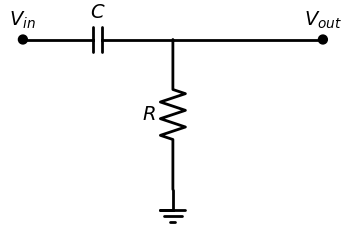

In [3]:

d = schem.Drawing()
d.add(e.Dot().label('$V_{in}$'))

d.add(e.Capacitor().label('$C$'))
d.push() 

d.add(e.Resistor().down().label('$R$'))

d.add(e.Ground())


d.pop()
d.add(e.Line().right())
d.add(e.Dot().label('$V_{out}$'))

d.draw()



In the Laplace domain its transfer function is defined as (see [Laplace Section](https://ringbuffer.org/dsp/Digital_Filters/Laplace%20Transform/#Analysing-a-Circuit-in-the-Laplace-Domain)):

$$
H(s) = \frac{Z_R}{Z_C+Z_R}
$$


$$
H(s) = \frac{R}{\frac{1}{sC} + R}
$$

$$
H(s) = \frac{sRC}{1 + sRC}
$$

$$
\tau = RC
$$

$$
\omega_c = \frac{1}{\tau} 
$$


$$
\omega_c = \frac{1}{RC} 
$$

$$
RC = \frac{1}{\omega_c } 
$$

---

$$
\boxed{H(s) = \frac{\frac{s}{\omega_c}}{1+ \frac{s}{\omega_c}} =  \frac{s}{\omega_c+s}}
$$


----

## Substitution

For a transform to the z-domain, the Laplace operator $s$ is subsstituted by the $z$ operator:

$$
s = \frac{2}{T}\frac{1-z^{-1}}{1+z^{-1}}
$$



The following steps rearrange the resulting transfer function to be comprised of two polynomials with $z^{-n}$:

$$
\begin{align} %
%
H(z) & = \frac{\frac{2}{T}\frac{1-z^{-1}}{1+z^{-1}}}{\omega_c + \frac{2}{T}\frac{1-z^{-1}}{1+z^{-1}}} \\
%
& = \frac{\frac{2}{T} (1-z^{-1})} {\omega_c (1+z^{-1}) + \frac{2}{T}(1-z^{-1})} \\
%
& = \frac{(1-z^{-1})} {\frac{T}{2} \omega_c (1+z^{-1}) + (1-z^{-1})} \\
%
& = \frac{1-z^{-1}} { \frac{T}{2} \omega_c + \frac{T}{2} \omega_cz^{-1}  + 1 -z^{-1}} \\
%
& = \frac{1-z^{-1}}{1+\frac{T}{2} \omega_c + (\frac{T}{2} \omega_c -1)z^{-1}} \\
%
& = \frac{  \frac{1}{1+\frac{T}{2} \omega_c} - \frac{1}{1+\frac{T}{2} \omega_c} z^{-1}}    {1 +  \frac{\frac{T}{2} \omega_c -1}{\frac{T}{2} \omega_c +1}z^{-1}}
\end{align}
$$



-----

## Coefficients

$$
H(z) = \frac{  \frac{1}{1+\frac{T}{2} \omega_c} - \frac{1}{1+\frac{T}{2} \omega_c} z^{-1}}    {1 +  \frac{\frac{T}{2} \omega_c -1}{\frac{T}{2} \omega_c +1}z^{-1}}
%
= \frac{b_0 + b_1 z^{-1}}{1+ a_1 z^{-1}}
$$





Following the above rearrangements, the coefficients can be directly extracted from the transfer funcion:


$$ 
\begin{align}
\mathbf b_0 = & \frac{1}{1+\frac{T}{2} \omega_c} \\
\mathbf b_1 = &	- \frac{1}{1+\frac{T}{2} \omega_c}  \\
\mathbf a_1 = &	\frac{\frac{T}{2} \omega_c -1}{\frac{T}{2} \omega_c +1}   \\
\end{align}
$$

-----




<div class="alert alert-block alert-info"> 
<b>Apply the Bilinear Transform</b> 
    
Create an IIR filter of this circuit with the bilinear transform. 

Find expressions for $a_n$ and $b_n$.


</div>

